# Distribución Binomial en Python

Este cuaderno para **Google Colab** muestra cómo trabajar la **distribución binomial**: cálculo de probabilidades, media, varianza, simulación, histograma y explicaciones de cada bloque de código.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom


## 1. Idea básica

La distribución binomial modela el número de éxitos en un número fijo de ensayos independientes.

Si $X\sim \mathrm{Binomial}(n,p)$, entonces:

$$P(X=k)=\binom{n}{k}p^k(1-p)^{n-k},\qquad k=0,1,\dots,n$$

donde:
- $n$ = número de ensayos,
- $p$ = probabilidad de éxito en cada ensayo.


In [2]:
# Parámetros de la distribución
n = 10
p = 0.3
print('n =', n)
print('p =', p)


n = 10
p = 0.3


## 2. Probabilidades

Usamos `binom.pmf`, `binom.cdf` y `binom.sf` para calcular probabilidades puntuales, acumuladas y de cola.


In [3]:
k = 4
print(f'P(X = {k})  = {binom.pmf(k, n, p):.6f}')
print(f'P(X <= {k}) = {binom.cdf(k, n, p):.6f}')
print(f'P(X >= {k}) = {binom.sf(k-1, n, p):.6f}')


P(X = 4)  = 0.200121
P(X <= 4) = 0.849732
P(X >= 4) = 0.350389


In [4]:
# Tabla de probabilidades
valores_k = np.arange(0, n+1)
probs = binom.pmf(valores_k, n, p)
print(' k   P(X=k)')
print('-'*18)
for k, pr in zip(valores_k, probs):
    print(f'{k:2d}   {pr:.6f}')


 k   P(X=k)
------------------
 0   0.028248
 1   0.121061
 2   0.233474
 3   0.266828
 4   0.200121
 5   0.102919
 6   0.036757
 7   0.009002
 8   0.001447
 9   0.000138
10   0.000006


## 3. Media y varianza

Para la binomial:

$$\mathbb{E}[X]=np,\qquad \mathrm{Var}(X)=np(1-p).$$


In [5]:
media = binom.mean(n, p)
varianza = binom.var(n, p)
print(f'Media teórica    = {media:.4f}')
print(f'Varianza teórica = {varianza:.4f}')


Media teórica    = 3.0000
Varianza teórica = 2.1000


## 4. Simulación

Generamos una muestra aleatoria para comparar la teoría con datos simulados.


In [6]:
np.random.seed(42)
muestra = np.random.binomial(n=n, p=p, size=1000)
print('Primeros 20 datos simulados:')
print(muestra[:20])


Primeros 20 datos simulados:
[2 5 4 3 2 2 1 5 3 4 0 6 4 2 2 2 2 3 3 2]


In [7]:
print(f'Media muestral    = {np.mean(muestra):.4f}')
print(f'Varianza muestral = {np.var(muestra):.4f}')


Media muestral    = 2.9350
Varianza muestral = 2.1008


## 5. Histograma y comparación con la distribución teórica


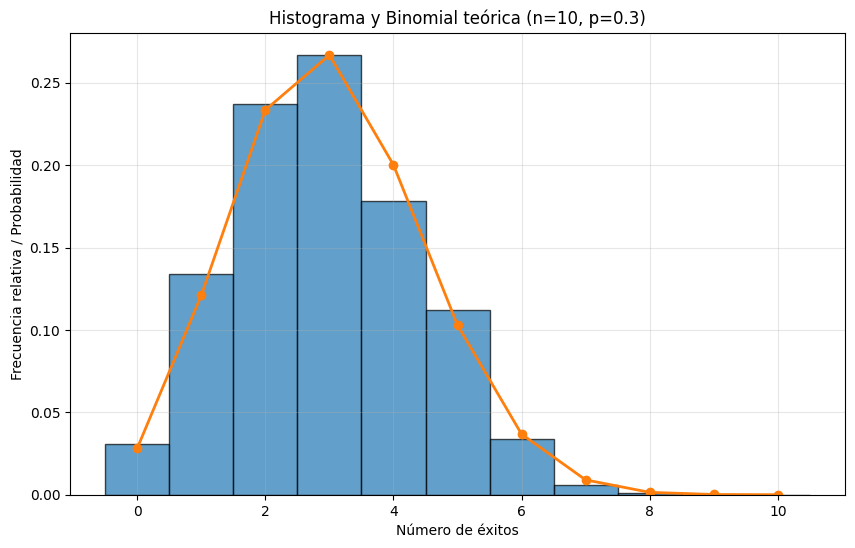

In [8]:
valores = np.arange(0, n+1)
pmf_teorica = binom.pmf(valores, n, p)

plt.figure(figsize=(10,6))
plt.hist(muestra, bins=np.arange(-0.5, n+1.5, 1), density=True, alpha=0.7, edgecolor='black')
plt.plot(valores, pmf_teorica, 'o-', linewidth=2)
plt.xlabel('Número de éxitos')
plt.ylabel('Frecuencia relativa / Probabilidad')
plt.title(f'Histograma y Binomial teórica (n={n}, p={p})')
plt.grid(alpha=0.3)
plt.show()


## 6. Función de probabilidad


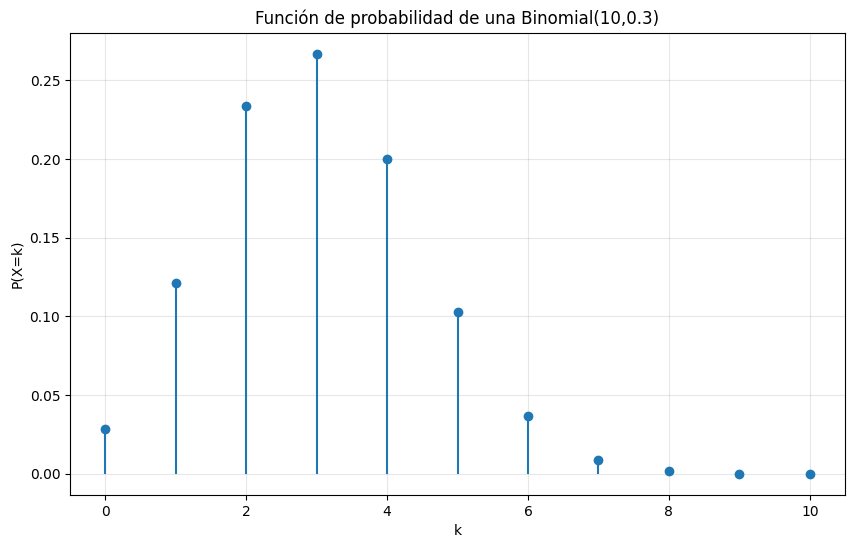

In [9]:
plt.figure(figsize=(10,6))
plt.stem(valores, pmf_teorica, basefmt=' ')
plt.xlabel('k')
plt.ylabel('P(X=k)')
plt.title(f'Función de probabilidad de una Binomial({n},{p})')
plt.grid(alpha=0.3)
plt.show()


## 7. Función reutilizable


In [10]:
def resumen_binomial(n, p, k):
    print(f'Distribución: Binomial(n={n}, p={p})')
    print(f'P(X = {k})  = {binom.pmf(k, n, p):.6f}')
    print(f'P(X <= {k}) = {binom.cdf(k, n, p):.6f}')
    print(f'P(X >= {k}) = {binom.sf(k-1, n, p):.6f}')
    print(f'Media       = {binom.mean(n, p):.4f}')
    print(f'Varianza    = {binom.var(n, p):.4f}')

resumen_binomial(12, 0.4, 5)


Distribución: Binomial(n=12, p=0.4)
P(X = 5)  = 0.227030
P(X <= 5) = 0.665209
P(X >= 5) = 0.561822
Media       = 4.8000
Varianza    = 2.8800


## 8. Caso de Estudio: Expansión de Mercado

**Escenario:** Una multinacional espera ingresar a un nuevo mercado con sus farmacias. Los estudios de mercado sugieren que la probabilidad de éxito es de $p = 0.35$.

### a) Probabilidad de éxito en expansión ($n=15$)
¿Cuál es la probabilidad de que al menos 7 farmacias tengan éxito?
$$P(X \ge 7) = 1 - P(X \le 6)$$

In [11]:
p_exito = 0.35
n_región = 15
prob_al_menos_7 = 1 - binom.cdf(6, n_región, p_exito)
print(f"Probabilidad de éxito expansivo: {prob_al_menos_7:.4f}")

Probabilidad de éxito expansivo: 0.2452


### b) Probabilidad de Quiebra
Si la primera farmacia exitosa no resulta antes de la quinta instalada, el proyecto fracasa.
$$P(\text{Quiebra}) = (1-p)^4$$

In [12]:
prob_quiebra = (1 - p_exito)**4
print(f"Riesgo de quiebra estimado: {prob_quiebra:.4f}")

Riesgo de quiebra estimado: 0.1785


### c) Probabilidad de Consolidación (Éxito Absoluto)
Si el tercer éxito aparece antes de la novena instalación, se considera un éxito absoluto.
$$P(Y_3 \le 8) = P(X_8 \ge 3)$$

In [13]:
prob_ext_abs = 1 - binom.cdf(2, 8, p_exito)
print(f"Probabilidad de éxito absoluto: {prob_ext_abs:.4f}")

Probabilidad de éxito absoluto: 0.5722
